# Chapter 12.2: Recommendation as Generation

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand the paradigm shift from discriminative (scoring) to generative (generating) recommendation
2. Implement autoregressive item generation using next-token prediction
3. Build an HSTU-style model that encodes all user actions as a token sequence
4. Apply beam search for generating top-K item recommendations
5. Implement constrained generation with business rules and category constraints
6. Compare generative vs discriminative recommendation quality and diversity
7. Analyze the trade-offs between generation speed and recommendation quality

## Prerequisites

- Understanding of autoregressive language models (GPT-style)
- Familiarity with sequential recommendation (Part 6)
- Knowledge of beam search decoding
- PyTorch proficiency

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part12/chapter_12.2_rec_as_generation.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part12/chapter_12.2_rec_as_generation.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import math
from collections import defaultdict

np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cpu')
print("All imports successful!")

All imports successful!


## 1. The Generative Recommendation Paradigm

### Discriminative vs Generative Recommendation

**Discriminative** (traditional): Score each candidate item independently.

$$\hat{y}_i = f(u, i) \quad \forall i \in \mathcal{I}$$

**Generative** (new paradigm): Autoregressively generate a sequence of recommended items.

$$P(i_1, i_2, \ldots, i_K | \text{history}) = \prod_{k=1}^{K} P(i_k | i_{<k}, \text{history})$$

This is analogous to how GPT generates text: instead of scoring all possible next words,
it generates tokens one at a time.

> **💡 Concept:** Generative recommendation naturally captures **item-item dependencies** in the
> recommended list. If item A is recommended first, the probability of item B changes — this
> automatically promotes diversity without explicit re-ranking.

In [2]:
# Generate synthetic sequential interaction data
def generate_sequential_data(n_users=300, n_items=200, n_categories=10,
                              max_seq_len=20, min_seq_len=5):
    """Generate synthetic user interaction sequences with categories."""
    # Assign items to categories
    item_categories = np.random.randint(0, n_categories, n_items)
    
    # User category preferences
    user_cat_prefs = np.random.dirichlet(np.ones(n_categories) * 0.5, n_users)
    
    sequences = []
    for user_id in range(n_users):
        seq_len = np.random.randint(min_seq_len, max_seq_len + 1)
        prefs = user_cat_prefs[user_id]
        
        seq = []
        for _ in range(seq_len):
            # Choose category based on preference
            cat = np.random.choice(n_categories, p=prefs)
            # Choose item within category
            cat_items = np.where(item_categories == cat)[0]
            if len(cat_items) > 0:
                item = np.random.choice(cat_items)
            else:
                item = np.random.randint(0, n_items)
            seq.append(item)
        
        sequences.append({
            'user_id': user_id,
            'items': seq,
            'categories': [int(item_categories[i]) for i in seq]
        })
    
    return sequences, item_categories

N_ITEMS = 200
N_CATEGORIES = 10
sequences, item_categories = generate_sequential_data(n_items=N_ITEMS, n_categories=N_CATEGORIES)
print(f"Generated {len(sequences)} user sequences")
print(f"Sample sequence (first 8 items): {sequences[0]['items'][:8]}")
print(f"Their categories: {sequences[0]['categories'][:8]}")

Generated 300 user sequences
Sample sequence (first 8 items): [60, 38, 190, 148, 98, 95]
Their categories: [3, 1, 3, 3, 8, 9]


## 2. Autoregressive Item Generation Model

We build a GPT-style model for item generation. The model sees a sequence of past items
and generates the next item autoregressively.

### Architecture

$$h_t = \text{CausalTransformer}(e_{i_1}, e_{i_2}, \ldots, e_{i_t})$$

$$P(i_{t+1} | i_{\leq t}) = \text{softmax}(W_o \cdot h_t)$$

where $e_{i_t}$ is the embedding of item $i_t$ and $W_o$ projects to the item vocabulary.

> **⚠️ Common Pitfall:** Unlike language models where the vocabulary is fixed, item vocabularies
> in recommendation change frequently. New items appear daily. This requires strategies for
> handling out-of-vocabulary items.

In [3]:
class GenerativeRecModel(nn.Module):
    """GPT-style autoregressive model for item recommendation."""
    
    def __init__(self, n_items, d_model=64, n_heads=4, n_layers=2,
                 max_seq_len=20, dropout=0.1):
        super().__init__()
        self.n_items = n_items
        self.d_model = d_model
        
        # Special tokens
        self.bos_token_id = n_items  # beginning of sequence
        self.total_tokens = n_items + 1
        
        self.item_embedding = nn.Embedding(self.total_tokens, d_model)
        self.position_embedding = nn.Embedding(max_seq_len + 1, d_model)
        self.dropout = nn.Dropout(dropout)
        
        # Causal Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Output projection (tied with input embedding)
        self.output_proj = nn.Linear(d_model, n_items)  # only real items
        
    def _generate_causal_mask(self, seq_len):
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        return mask
    
    def forward(self, item_seq):
        """Forward pass for training.
        item_seq: (batch, seq_len) - input item IDs
        Returns logits: (batch, seq_len, n_items)
        """
        batch_size, seq_len = item_seq.shape
        
        # Embeddings
        positions = torch.arange(seq_len, device=item_seq.device).unsqueeze(0).expand(batch_size, -1)
        x = self.item_embedding(item_seq) + self.position_embedding(positions)
        x = self.dropout(x)
        
        # Causal mask
        causal_mask = self._generate_causal_mask(seq_len).to(item_seq.device)
        
        # Transformer
        hidden = self.transformer(x, mask=causal_mask)
        
        # Project to item logits
        logits = self.output_proj(hidden)
        return logits

gen_model = GenerativeRecModel(n_items=N_ITEMS)
n_params = sum(p.numel() for p in gen_model.parameters())
print(f"Generative Rec Model: {n_params:,} parameters")

Generative Rec Model: 127,176 parameters


In [4]:
# Prepare training data
class SeqRecDataset(Dataset):
    def __init__(self, sequences, max_len=20, bos_token_id=200):
        self.data = []
        for seq_data in sequences:
            items = seq_data['items']
            # Create input (BOS + items[:-1]) and target (items)
            input_seq = [bos_token_id] + items[:-1]
            target_seq = items
            # Truncate/pad to max_len
            input_seq = input_seq[:max_len]
            target_seq = target_seq[:max_len]
            pad_len = max_len - len(input_seq)
            input_seq = input_seq + [0] * pad_len
            target_seq = target_seq + [-1] * pad_len  # -1 = ignore
            self.data.append((input_seq, target_seq))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        inp, tgt = self.data[idx]
        return torch.tensor(inp, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

# Split
split_idx = int(0.8 * len(sequences))
train_seqs = sequences[:split_idx]
val_seqs = sequences[split_idx:]

train_ds = SeqRecDataset(train_seqs, bos_token_id=N_ITEMS)
val_ds = SeqRecDataset(val_seqs, bos_token_id=N_ITEMS)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Train: 240, Val: 60


In [5]:
# Train the generative model
def train_generative_model(model, train_loader, val_loader, n_epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for inp, tgt in train_loader:
            logits = model(inp)  # (batch, seq_len, n_items)
            loss = criterion(logits.reshape(-1, model.n_items), tgt.reshape(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for inp, tgt in val_loader:
                logits = model(inp)
                loss = criterion(logits.reshape(-1, model.n_items), tgt.reshape(-1))
                val_loss += loss.item()
                preds = logits.argmax(dim=-1)
                mask = tgt != -1
                correct += (preds[mask] == tgt[mask]).sum().item()
                total += mask.sum().item()
        
        n_train = len(train_loader)
        n_val = len(val_loader)
        acc = correct / total if total > 0 else 0
        history['train_loss'].append(total_loss / n_train)
        history['val_loss'].append(val_loss / n_val)
        history['val_acc'].append(acc)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {total_loss/n_train:.4f}, "
                  f"Val Loss: {val_loss/n_val:.4f}, Val Acc: {acc:.4f}")
    
    return history

gen_model = GenerativeRecModel(n_items=N_ITEMS)
history = train_generative_model(gen_model, train_loader, val_loader)

Epoch 5/20 - Train Loss: 5.1300, Val Loss: 5.3965, Val Acc: 0.0057


Epoch 10/20 - Train Loss: 4.8493, Val Loss: 5.4596, Val Acc: 0.0043


Epoch 15/20 - Train Loss: 4.5764, Val Loss: 5.5223, Val Acc: 0.0028


Epoch 20/20 - Train Loss: 4.2960, Val Loss: 5.6092, Val Acc: 0.0028


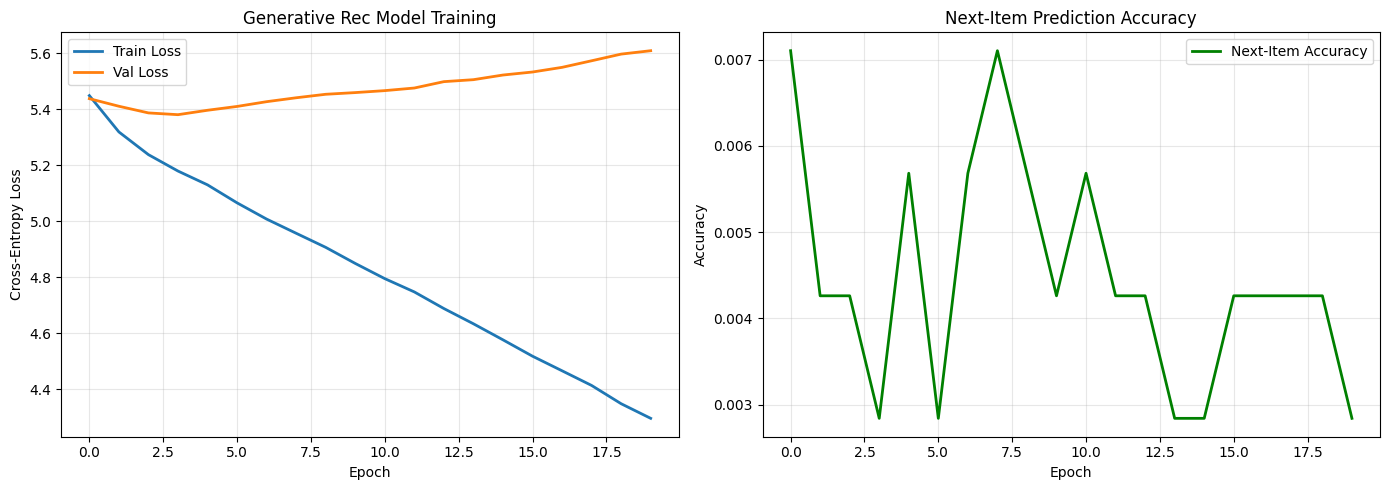

In [6]:
# Visualize training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Generative Rec Model Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_acc'], label='Next-Item Accuracy', linewidth=2, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Next-Item Prediction Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. HSTU-Style Action Tokenization

The HSTU (Hierarchical Sequential Transduction Unit) approach encodes **all user actions**
as tokens in a unified sequence:

- Click on item A -> `[CLICK, item_A]`
- Add to cart item B -> `[CART, item_B]`
- Purchase item C -> `[PURCHASE, item_C]`
- Rate item D 5 stars -> `[RATE_5, item_D]`

$$\text{Sequence} = [\text{action}_1, \text{item}_1, \text{action}_2, \text{item}_2, \ldots]$$

> **🔑 Pro Tip:** By encoding action types as tokens, the model learns that a purchase signal
> is stronger than a click. This naturally weights different feedback types without explicit
> engineering.

In [7]:
# Generate action-enriched sequences
ACTION_TYPES = {'click': 0, 'cart': 1, 'purchase': 2, 'rate': 3}
N_ACTION_TYPES = len(ACTION_TYPES)

def generate_action_sequences(n_users=300, n_items=200, max_actions=30):
    """Generate sequences with action types."""
    action_probs = [0.5, 0.2, 0.15, 0.15]  # click, cart, purchase, rate
    
    sequences = []
    for user_id in range(n_users):
        n_actions = np.random.randint(5, max_actions + 1)
        actions = []
        for _ in range(n_actions):
            action = np.random.choice(list(ACTION_TYPES.values()), p=action_probs)
            item = np.random.randint(0, n_items)
            actions.append((action, item))
        sequences.append({'user_id': user_id, 'actions': actions})
    
    return sequences

class HSTUModel(nn.Module):
    """Simplified HSTU-style model with action tokens."""
    
    def __init__(self, n_items=200, n_actions=4, d_model=64, n_heads=4,
                 n_layers=2, max_seq_len=60):
        super().__init__()
        self.n_items = n_items
        self.n_actions = n_actions
        
        # Token embeddings: [action_tokens, item_tokens, special_tokens]
        self.action_embedding = nn.Embedding(n_actions, d_model)
        self.item_embedding = nn.Embedding(n_items + 1, d_model)  # +1 for BOS
        self.position_embedding = nn.Embedding(max_seq_len, d_model)
        self.token_type_embedding = nn.Embedding(2, d_model)  # 0=action, 1=item
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.item_predictor = nn.Linear(d_model, n_items)
    
    def forward(self, action_ids, item_ids, token_types):
        """Forward pass.
        action_ids: (batch, seq_len) action token IDs
        item_ids: (batch, seq_len) item token IDs
        token_types: (batch, seq_len) 0 for action, 1 for item
        """
        batch_size, seq_len = action_ids.shape
        
        # Merge embeddings based on token type
        action_emb = self.action_embedding(action_ids)
        item_emb = self.item_embedding(item_ids)
        type_mask = token_types.unsqueeze(-1).float()
        token_emb = (1 - type_mask) * action_emb + type_mask * item_emb
        
        positions = torch.arange(seq_len, device=action_ids.device).unsqueeze(0).expand(batch_size, -1)
        x = token_emb + self.position_embedding(positions) + self.token_type_embedding(token_types)
        
        # Causal mask
        causal_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool().to(x.device)
        hidden = self.transformer(x, mask=causal_mask)
        
        logits = self.item_predictor(hidden)
        return logits

hstu_model = HSTUModel()
print(f"HSTU Model: {sum(p.numel() for p in hstu_model.parameters()):,} parameters")

# Quick test
batch_actions = torch.randint(0, 4, (2, 10))
batch_items = torch.randint(0, 200, (2, 10))
batch_types = torch.tensor([[0,1,0,1,0,1,0,1,0,1], [0,1,0,1,0,1,0,1,0,1]])
logits = hstu_model(batch_actions, batch_items, batch_types)
print(f"Output shape: {logits.shape}")  # (2, 10, 200)

HSTU Model: 130,056 parameters
Output shape: torch.Size([2, 10, 200])


## 4. Beam Search for Top-K Generation

Unlike greedy decoding which picks the single most likely item at each step,
**beam search** maintains the top-B most likely partial sequences:

$$\text{Score}(i_1, \ldots, i_k) = \sum_{j=1}^{k} \log P(i_j | i_{<j}, \text{history})$$

> **💡 Concept:** Beam search is crucial for generative recommendation because greedy decoding
> tends to produce repetitive, low-diversity lists. Beam search explores more of the item space.

In [8]:
def greedy_generate(model, context, n_generate=5):
    """Greedy autoregressive generation."""
    model.eval()
    generated = list(context)
    
    with torch.no_grad():
        for _ in range(n_generate):
            inp = torch.tensor([generated], dtype=torch.long)
            logits = model(inp)  # (1, seq_len, n_items)
            next_logits = logits[0, -1, :]  # Last position
            next_item = next_logits.argmax().item()
            generated.append(next_item)
    
    return generated[len(context):]


def beam_search_generate(model, context, n_generate=5, beam_width=5):
    """Beam search for top-K item generation."""
    model.eval()
    
    # Initialize beams: (score, sequence)
    beams = [(0.0, list(context))]
    
    with torch.no_grad():
        for step in range(n_generate):
            candidates = []
            
            for score, seq in beams:
                inp = torch.tensor([seq], dtype=torch.long)
                logits = model(inp)
                log_probs = F.log_softmax(logits[0, -1, :], dim=-1)
                
                # Get top-k next items
                top_scores, top_items = log_probs.topk(beam_width)
                
                for i in range(beam_width):
                    new_score = score + top_scores[i].item()
                    new_seq = seq + [top_items[i].item()]
                    candidates.append((new_score, new_seq))
            
            # Keep top beam_width candidates
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_width]
    
    # Return all beam results
    results = []
    for score, seq in beams:
        results.append({
            'items': seq[len(context):],
            'score': score
        })
    return results

# Generate recommendations
context = [gen_model.bos_token_id] + sequences[0]['items'][:5]
print(f"Context (last 5 items): {context[-5:]}")
print(f"\nGreedy generation: {greedy_generate(gen_model, context)}")
print(f"\nBeam search results:")
for i, result in enumerate(beam_search_generate(gen_model, context)):
    print(f"  Beam {i+1}: items={result['items']}, score={result['score']:.4f}")

Context (last 5 items): [60, 38, 190, 148, 98]

Greedy generation: [1, 160, 39, 55, 11]

Beam search results:
  Beam 1: items=[1, 160, 50, 55, 11], score=-15.1557
  Beam 2: items=[1, 160, 50, 55, 29], score=-15.5701
  Beam 3: items=[1, 160, 8, 148, 167], score=-15.6044
  Beam 4: items=[1, 160, 39, 55, 11], score=-15.7000
  Beam 5: items=[1, 160, 50, 55, 116], score=-15.7736


## 5. Constrained Generation

In practice, recommendations must satisfy business constraints:
- **Category diversity**: at most 3 items from the same category
- **No repeats**: don't recommend items already consumed
- **Genre balance**: at least 1 item from each preferred genre

We implement these as **logit masking** during generation:

$$\tilde{P}(i | \text{context}) = \begin{cases} 0 & \text{if } i \text{ violates constraint} \\ P(i | \text{context}) & \text{otherwise} \end{cases}$$

> **🔑 Pro Tip:** Constrained generation in recommendation is analogous to constrained decoding
> in NLP (e.g., forcing JSON output). The technique is the same: mask out invalid tokens
> before the softmax.

In [9]:
def constrained_beam_search(model, context, item_categories, n_generate=5,
                             beam_width=5, max_per_category=2, exclude_items=None):
    """Beam search with category diversity and exclusion constraints."""
    model.eval()
    exclude_items = set(exclude_items or [])
    
    # Each beam tracks: (score, sequence, category_counts)
    beams = [(0.0, list(context), defaultdict(int))]
    
    with torch.no_grad():
        for step in range(n_generate):
            candidates = []
            
            for score, seq, cat_counts in beams:
                inp = torch.tensor([seq], dtype=torch.long)
                logits = model(inp)
                next_logits = logits[0, -1, :].clone()
                
                # Apply constraints: mask out invalid items
                for item_id in range(len(next_logits)):
                    # Exclude already consumed items
                    if item_id in exclude_items:
                        next_logits[item_id] = float('-inf')
                    # Exclude already recommended items
                    if item_id in seq[len(context):]:
                        next_logits[item_id] = float('-inf')
                    # Category constraint
                    if item_id < len(item_categories):
                        cat = item_categories[item_id]
                        if cat_counts[cat] >= max_per_category:
                            next_logits[item_id] = float('-inf')
                
                log_probs = F.log_softmax(next_logits, dim=-1)
                top_scores, top_items = log_probs.topk(min(beam_width, (next_logits != float('-inf')).sum().item()))
                
                for i in range(len(top_items)):
                    new_cat_counts = defaultdict(int, cat_counts)
                    item_id = top_items[i].item()
                    if item_id < len(item_categories):
                        new_cat_counts[item_categories[item_id]] += 1
                    candidates.append((
                        score + top_scores[i].item(),
                        seq + [item_id],
                        new_cat_counts
                    ))
            
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_width]
    
    results = []
    for score, seq, cat_counts in beams:
        items = seq[len(context):]
        cats = [int(item_categories[i]) for i in items if i < len(item_categories)]
        results.append({'items': items, 'categories': cats, 'score': score})
    return results

# Compare unconstrained vs constrained generation
exclude = set(sequences[0]['items'][:5])  # Already seen items

print("Unconstrained beam search:")
for r in beam_search_generate(gen_model, context, n_generate=8)[:3]:
    cats = [int(item_categories[i]) for i in r['items'] if i < N_ITEMS]
    print(f"  Items: {r['items']}, Categories: {cats}, Unique cats: {len(set(cats))}")

print("\nConstrained beam search (max 2 per category):")
for r in constrained_beam_search(gen_model, context, item_categories,
                                   n_generate=8, max_per_category=2, exclude_items=exclude)[:3]:
    print(f"  Items: {r['items']}, Categories: {r['categories']}, Unique cats: {len(set(r['categories']))}")

Unconstrained beam search:


  Items: [1, 160, 50, 55, 11, 187, 96, 31], Categories: [3, 5, 2, 3, 7, 9, 8, 2], Unique cats: 6
  Items: [1, 160, 39, 55, 11, 187, 96, 31], Categories: [3, 5, 3, 3, 7, 9, 8, 2], Unique cats: 6
  Items: [1, 160, 50, 55, 11, 187, 96, 41], Categories: [3, 5, 2, 3, 7, 9, 8, 1], Unique cats: 7

Constrained beam search (max 2 per category):


  Items: [1, 160, 50, 55, 11, 187, 96, 31], Categories: [3, 5, 2, 3, 7, 9, 8, 2], Unique cats: 6
  Items: [1, 160, 50, 55, 149, 192, 5, 77], Categories: [3, 5, 2, 3, 8, 7, 9, 8], Unique cats: 6
  Items: [1, 160, 50, 55, 11, 187, 96, 41], Categories: [3, 5, 2, 3, 7, 9, 8, 1], Unique cats: 7


/var/folders/fm/hwpyrzvx207290wd3x3n9zgh0000gn/T/ipykernel_78280/3040570898.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([greedy_div, beam_div, constr_div],


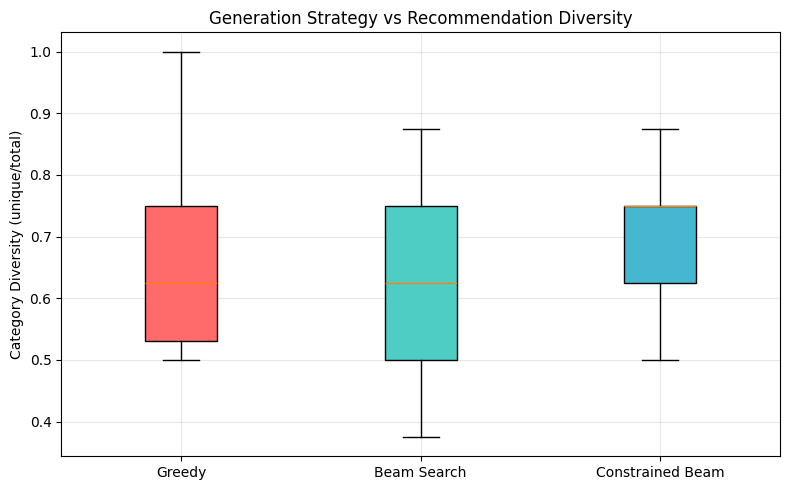

Mean diversity - Greedy: 0.652, Beam: 0.640, Constrained: 0.703


In [10]:
# Visualize diversity comparison
def measure_diversity(recommendations, item_categories, n_trials=50):
    """Measure category diversity of recommendations."""
    diversities = []
    for rec_list in recommendations:
        cats = [int(item_categories[i]) for i in rec_list if i < len(item_categories)]
        if cats:
            diversity = len(set(cats)) / len(cats)
            diversities.append(diversity)
    return diversities

# Generate many recommendations with both methods
greedy_recs = []
beam_recs = []
constrained_recs = []

for seq_data in sequences[:50]:
    ctx = [gen_model.bos_token_id] + seq_data['items'][:5]
    greedy_recs.append(greedy_generate(gen_model, ctx, n_generate=8))
    beam_results = beam_search_generate(gen_model, ctx, n_generate=8)
    beam_recs.append(beam_results[0]['items'] if beam_results else [])
    constr_results = constrained_beam_search(gen_model, ctx, item_categories,
                                              n_generate=8, max_per_category=2)
    constrained_recs.append(constr_results[0]['items'] if constr_results else [])

greedy_div = measure_diversity(greedy_recs, item_categories)
beam_div = measure_diversity(beam_recs, item_categories)
constr_div = measure_diversity(constrained_recs, item_categories)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([greedy_div, beam_div, constr_div],
                labels=['Greedy', 'Beam Search', 'Constrained Beam'],
                patch_artist=True)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel('Category Diversity (unique/total)')
ax.set_title('Generation Strategy vs Recommendation Diversity')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean diversity - Greedy: {np.mean(greedy_div):.3f}, "
      f"Beam: {np.mean(beam_div):.3f}, Constrained: {np.mean(constr_div):.3f}")

## 🏋️ Exercise 1: Implement Temperature Sampling

Add temperature-controlled sampling to the generation process. Higher temperature
increases diversity (exploration), lower temperature increases relevance (exploitation).

$$P(i) = \frac{\exp(\text{logit}_i / \tau)}{\sum_j \exp(\text{logit}_j / \tau)}$$

In [11]:
# TODO: Implement temperature sampling for item generation
def temperature_generate(model, context, n_generate=5, temperature=1.0, top_k=50):
    """Generate items with temperature-controlled sampling."""
    # TODO:
    # 1. Get logits from the model
    # 2. Apply temperature scaling: logits / temperature
    # 3. Apply top-k filtering
    # 4. Sample from the distribution
    # 5. Return the generated item sequence
    pass

# Test with different temperatures and compare diversity
print("Exercise 1: Implement temperature_generate")

Exercise 1: Implement temperature_generate


## 🏋️ Exercise 2: Implement Nucleus (Top-p) Sampling

Implement top-p (nucleus) sampling where you sample from the smallest set of items
whose cumulative probability exceeds $p$.

In [12]:
# TODO: Implement nucleus sampling
def nucleus_generate(model, context, n_generate=5, top_p=0.9):
    """Generate items with nucleus (top-p) sampling."""
    # TODO:
    # 1. Get logits and compute probabilities
    # 2. Sort by probability descending
    # 3. Find the cutoff where cumulative prob > top_p
    # 4. Zero out probabilities below cutoff
    # 5. Renormalize and sample
    pass

print("Exercise 2: Implement nucleus_generate")

Exercise 2: Implement nucleus_generate


## 🏋️ Exercise 3: Build a Discriminative Baseline and Compare

Build a simple discriminative model (dot-product scoring) and compare its recommendations
with the generative model in terms of accuracy and diversity.

In [13]:
# TODO: Build a discriminative recommender and compare with generative
class DiscriminativeRec(nn.Module):
    def __init__(self, n_items=200, d_model=64):
        super().__init__()
        # TODO: Implement a simple sequence encoder + dot-product scoring
        pass
    
    def forward(self, item_seq):
        # TODO: Encode sequence, score all items
        pass

# TODO: Train the discriminative model
# TODO: Compare accuracy and diversity with the generative model
print("Exercise 3: Build and compare discriminative vs generative recommender")

Exercise 3: Build and compare discriminative vs generative recommender


## Summary

In this notebook, we explored the generative recommendation paradigm:

1. **Paradigm shift**: From scoring items independently to generating item sequences autoregressively
2. **GPT-style architecture**: Causal Transformer for next-item prediction
3. **HSTU approach**: Encoding all user actions (clicks, purchases, ratings) as token sequences
4. **Beam search**: Generating diverse top-K recommendations by exploring multiple paths
5. **Constrained generation**: Enforcing business rules through logit masking

### Key Takeaways

- Generative models naturally capture item-item dependencies in the recommended list
- Constrained generation is more elegant than post-hoc re-ranking for enforcing rules
- The trade-off is computational cost: generation is sequential, unlike batch scoring
- Temperature and nucleus sampling provide fine-grained diversity control